## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt

In [2]:
data_dir = "../data"
print(os.listdir(data_dir))

['clean', 'exp1_14drivers_14cars_dailyRoutes.csv', 'exp2_19drivers_1car_1route.csv', 'exp3_4drivers_1car_1route.csv']


In [5]:
drivers_14 = pd.read_csv(os.path.join(data_dir, "exp1_14drivers_14cars_dailyRoutes.csv"))
drivers_19 = pd.read_csv(os.path.join(data_dir, "../data/exp2_19drivers_1car_1route.csv"))
drivers_4 = pd.read_csv(os.path.join(data_dir, "../data/exp3_4drivers_1car_1route.csv"))

C:\Users\codin\AppData\Local\Temp/ipykernel_1864/1020209130.py:1: DtypeWarning: Columns (1,2,4,5,6,9,10,14,15,16,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  drivers_14 = pd.read_csv(os.path.join(data_dir, "exp1_14drivers_14cars_dailyRoutes.csv"))


## Preprocessing

In [6]:
float_columns = [
    "AIR_INTAKE_TEMP",
    "AMBIENT_AIR_TEMP",
    "ENGINE_COOLANT_TEMP",
    "ENGINE_LOAD",
    "EQUIV_RATIO",
    "MAF", "SPEED",
    "THROTTLE_POS",
    "FUEL_LEVEL",
    "INTAKE_MANIFOLD_PRESSURE"
]

int_columns = [
    "ENGINE_RPM"
]

needed_columns = float_columns + int_columns

drivers_4 = drivers_4[needed_columns]
drivers_14 = drivers_14[needed_columns]
drivers_19 = drivers_19[needed_columns]

# Remove missing rows
drivers_4 = drivers_4.dropna(axis=0)
drivers_14 = drivers_14.dropna(axis=0)
drivers_19 = drivers_19.dropna(axis=0)


# some of the columns in the dataframes are not float-types. We need to convert them to float
# some of the columns contain the unit of the measured data which is redundant.

units = ["C", "c", "%", "g/c", "km/h"]

for column in needed_columns:
    drivers_4[column] = drivers_4[column].apply(lambda x: str(x).replace(",", "."))
    drivers_14[column] = drivers_4[column].apply(lambda x: str(x).replace(",", "."))
    drivers_19[column] = drivers_4[column].apply(lambda x: str(x).replace(",", "."))
    
    for unit in units:
        drivers_4[column] = drivers_4[column].apply(lambda x: str(x).replace(unit, ""))
        drivers_14[column] = drivers_4[column].apply(lambda x: str(x).replace(unit, ""))
        drivers_19[column] = drivers_4[column].apply(lambda x: str(x).replace(unit, ""))

        
# asign the correct dtype

drivers_4 = drivers_4.astype(np.float32)
drivers_4[int_columns] = drivers_4[int_columns].astype(np.int32)

drivers_14 = drivers_14.astype(np.float32)
drivers_14[int_columns] = drivers_14[int_columns].astype(np.int32)

drivers_19 = drivers_19.astype(np.float32)
drivers_19[int_columns] = drivers_19[int_columns].astype(np.int32)


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## EDA

In [176]:
drivers_4_corr = drivers_4.corr()
drivers_14_corr = drivers_14.corr()
drivers_19_corr = drivers_19.corr()


<AxesSubplot:>

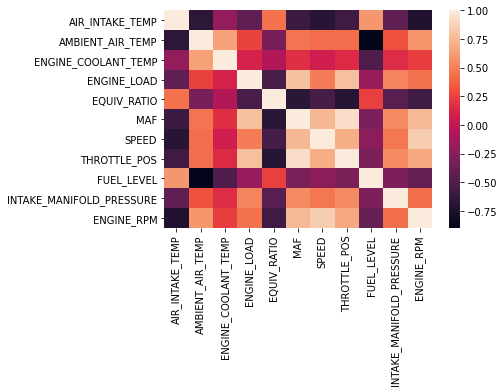

In [177]:
seaborn.heatmap(drivers_4_corr)

<AxesSubplot:>

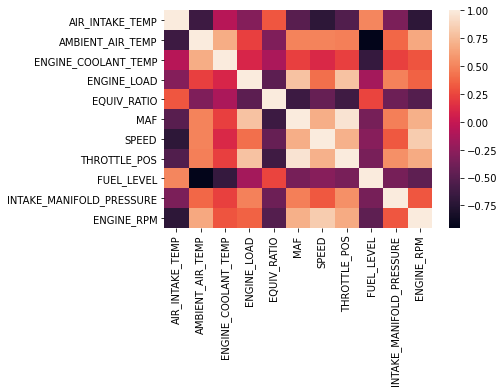

In [170]:

seaborn.heatmap(drivers_14_corr)


<AxesSubplot:>

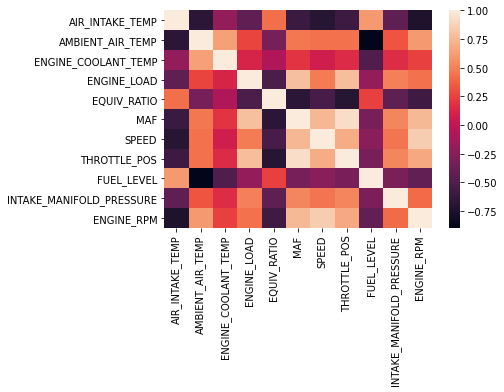

In [171]:
seaborn.heatmap(drivers_19_corr)

## Useful correlations among variables

*POS (Positive correlation)*

*NEG (Negative correlation)*



- AIR_INTAKE - AMBIENT_AIR_TEMP (POS)

- AIR_INTAKE - MAF (NEG)

- AIR_INTAKE - SPEED (NEG)

- AIR_INTAKE - FUEL_INTAKE (POS)

- AIR_INTAKE - ENGINE_RPM (NEG)


- AMBIENT_AIR_TEMP - (POS)

- AMBIENT_AIR_TEMP - MAF (POS)

- AMBIENT_AIR_TEMP - THROTTLE_POS (POS)

- AMBIENT_AIR_TEMP - FUEL_LEVEL (NEG)

- AMBIENT_AIR_TEMP - ENGINE_RPM (POS)


- ENGINE_COOLANT_TEMP - FUEL LEVEL (NEG)


- ENGINE_LOAD - MAF (POS)

- ENGINE_LOAD - THROTTLE_POS (POS)

- ENGINE_LOAD - EQUIV_RATIO (NEG)


- EQUIV_RATIO - MAF (NEG)

- EQUIV_RATIO - THROTTLE_POS (NEG)

- EQUIV_RATIO - ENGINE_RPM (NEG)


- THROTTLE_POS - MAF (POS)

- THROTTLE_POS - ENGINE_LOAD (POS)


- ENGINE_RPM - SPEED (POS)

In [179]:
drivers_4.to_csv("drivers_4_clean.csv")
drivers_14.to_csv("drivers_14_clean.csv")
drivers_19.to_csv("drivers_19_clean.csv")